<a href="https://colab.research.google.com/github/isegura/tema4_plndeep/blob/main/cargar_modelo_preentrenado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar modelo pre-entrenado de word embeddings

En este notebook, aprenderemos a cargar un modelo ya pre-entrenado.



In [ ]:
!pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.0 MB/s eta 0:00:00


Vamos a cargar el modelo pre-entrenado  **glove-wiki-gigaword-50**. La dimensión de sus embeddings es 50. Tiene un vocabulario de unas 400.000 palabras (70MB). Tarda en cargar 5-10 segundos.


In [ ]:
import gensim.downloader as api
model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


Vemos alguas propiedades del modelo:

In [ ]:
print("Tamaño del vocabulario:", len(model))
print("Dimensión de los embeddings:", model.vector_size)

Tamaño del vocabulario: 400000
Dimensión de los embeddings: 50


Consultamos algunas palabras del diccionario:

In [ ]:
list(model.index_to_key[:20])

['the',
 ',',
 '.',
 'of',
 'to',
 'and',
 'in',
 'a',
 '"',
 "'s",
 'for',
 '-',
 'that',
 'on',
 'is',
 'was',
 'said',
 'with',
 'he',
 'as']

Muestra las palabras más similares a "dog".

- ¿Qué palabras aparecen?
- ¿Son semánticamente similares?

In [ ]:
model.most_similar("dog")

[('cat', 0.9218004941940308),
 ('dogs', 0.8513158559799194),
 ('horse', 0.7907583713531494),
 ('puppy', 0.7754920721054077),
 ('pet', 0.7724708318710327),
 ('rabbit', 0.7720814347267151),
 ('pig', 0.7490062117576599),
 ('snake', 0.7399188876152039),
 ('baby', 0.7395570278167725),
 ('bite', 0.7387937307357788)]

Prueba con otras palabras, ¿el método **most_similar** devuelve palabras relacionadas semánticamente?.

In [ ]:
for w in ['king', 'car', 'computer']:
    print("Similar to ", w, ":", model.most_similar(w))


Similar to  king : [('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721), ('uncle', 0.7627150416374207), ('kingdom', 0.7542160749435425), ('throne', 0.7539913654327393), ('brother', 0.7492411136627197), ('ruler', 0.7434253692626953)]
Similar to  car : [('truck', 0.92085862159729), ('cars', 0.8870189785957336), ('vehicle', 0.8833683729171753), ('driver', 0.8464019298553467), ('driving', 0.8384189009666443), ('bus', 0.8210511803627014), ('vehicles', 0.8174992799758911), ('parked', 0.7902189493179321), ('motorcycle', 0.7866503000259399), ('taxi', 0.7833929657936096)]
Similar to  computer : [('computers', 0.9165045022964478), ('software', 0.8814992904663086), ('technology', 0.852556049823761), ('electronic', 0.812586784362793), ('internet', 0.8060455322265625), ('computing', 0.802603542804718), ('devices', 0.8016185760498047), ('digital', 0.7991793751716614), ('applications', 0.791274070739746

El método **similarity** mide la similitud entre palabras. Prueba con distintos pares de palabras.

In [ ]:
# Tiene una similitud de 0.92, porque cat y dog están relacionados semánticamente
model.similarity("cat", "dog")


np.float32(0.9218005)

In [ ]:
model.similarity("doctor", "nurse")

np.float32(0.79774976)

In [ ]:
# sin embargo, cat y car, tienen un similitud de 0.36.
model.similarity("cat", "car")


np.float32(0.36382526)

## Detectar analogías.

Una de las propiedades más interesantes de los modelos de word embeddings es que permiten detectar analogías mediante operaciones vectoriales.

Piensa en la relación:
King - man + woman,
¿qué debería ser?

Si realizamos esas operaciones vectoriales, el vector resultante es el de la palabra queen.

Este comportamiento muestra que los word embeddings no solo capturan similitud entre palabras, sino también relaciones semánticas entre conceptos.


In [ ]:
model.most_similar(positive=["king", "woman"], negative=["man"])

[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.7592144012451172),
 ('daughter', 0.7473883628845215),
 ('elizabeth', 0.7460219860076904),
 ('princess', 0.7424570322036743),
 ('kingdom', 0.7337412238121033),
 ('monarch', 0.721449077129364),
 ('eldest', 0.7184861898422241),
 ('widow', 0.7099431157112122)]

Paris - France + Italy -> debería dar Rome


In [ ]:
model.most_similar(positive=["paris", "italy"], negative=["france"])

[('rome', 0.8465589284896851),
 ('milan', 0.7766007781028748),
 ('turin', 0.7666355967521667),
 ('venice', 0.7591592073440552),
 ('madrid', 0.7565805315971375),
 ('italian', 0.7513630986213684),
 ('aires', 0.7429094910621643),
 ('naples', 0.7406354546546936),
 ('buenos', 0.7357348203659058),
 ('lisbon', 0.7244544625282288)]

Propón distintas analogías:

## Singular - plural


In [ ]:
model.most_similar(positive=["cars", "dog"], negative=["car"])

[('dogs', 0.8964272141456604),
 ('cat', 0.8243923187255859),
 ('cats', 0.8015597462654114),
 ('horses', 0.7977336645126343),
 ('animals', 0.7690971493721008),
 ('eat', 0.7646284699440002),
 ('pigs', 0.7474110126495361),
 ('pet', 0.7376480102539062),
 ('pets', 0.7345165014266968),
 ('breed', 0.733655571937561)]

## Adjetivos comparativos

In [ ]:
model.most_similar(positive=["smaller", "big"], negative=["small"])

[('bigger', 0.8704497218132019),
 ('competitors', 0.7594608664512634),
 ('lose', 0.743256688117981),
 ('biggest', 0.7407416701316833),
 ('coming', 0.7391999363899231),
 ('expect', 0.7388766407966614),
 ('even', 0.7384443879127502),
 ('make', 0.7370075583457947),
 ('better', 0.7345830798149109),
 ('much', 0.7344986796379089)]

In [ ]:
model.most_similar(positive=["smallest", "fast"], negative=["small"])

[('fastest', 0.763831377029419),
 ('slower', 0.7336891889572144),
 ('slowest', 0.7325396537780762),
 ('overall', 0.69968581199646),
 ('weakest', 0.6994820237159729),
 ('quickest', 0.689086377620697),
 ('surpass', 0.6636300683021545),
 ('faster', 0.6547054052352905),
 ('pace', 0.6528194546699524),
 ('lowest', 0.6394984722137451)]

## Pronombres

His - He + She -> her

In [ ]:
model.most_similar(positive=["his", "she"], negative=["he"])

[('her', 0.9928844571113586),
 ('herself', 0.8991193175315857),
 ('mother', 0.8644037842750549),
 ('woman', 0.8402841687202454),
 ('my', 0.8388473987579346),
 ('wife', 0.823907732963562),
 ('him', 0.815402626991272),
 ('friend', 0.8139099478721619),
 ('husband', 0.810576856136322),
 ('couple', 0.8069899678230286)]

Variación verbal (el que probaste)

In [ ]:
model.most_similar(positive=["walking", "swimming"], negative=["walk"])

[('rowing', 0.7639790773391724),
 ('canoeing', 0.7431256175041199),
 ('diving', 0.7370901703834534),
 ('skiing', 0.7224119901657104),
 ('swimmers', 0.7112765908241272),
 ('volleyball', 0.7014796733856201),
 ('biking', 0.6979694962501526),
 ('skating', 0.6889318823814392),
 ('equestrian', 0.6877797245979309),
 ('fencing', 0.6875166893005371)]

Los embeddings clásicos capturan muy bien relaciones semánticas, pero no siempre representan correctamente relaciones morfológicas como los gerundios, porque estas dependen de reglas gramaticales y no solo de los contextos en los que aparecen las palabras.

## Palabra intrunsa

In [ ]:
model.doesnt_match(["dog", "cat", "cow", "car"])

'car'

In [ ]:
model.doesnt_match(["breakfast", "lunch", "dinner", "car"])

'car'

## Encontrar sesgos

In [ ]:
model.most_similar(positive=["doctor", "woman"], negative=["man"])

[('nurse', 0.8404642939567566),
 ('child', 0.7663259506225586),
 ('pregnant', 0.7570130228996277),
 ('mother', 0.7517457604408264),
 ('patient', 0.7516663074493408),
 ('physician', 0.7507280707359314),
 ('dentist', 0.7360344529151917),
 ('therapist', 0.7342537045478821),
 ('parents', 0.7286345958709717),
 ('surgeon', 0.7165213823318481)]

## Visualización

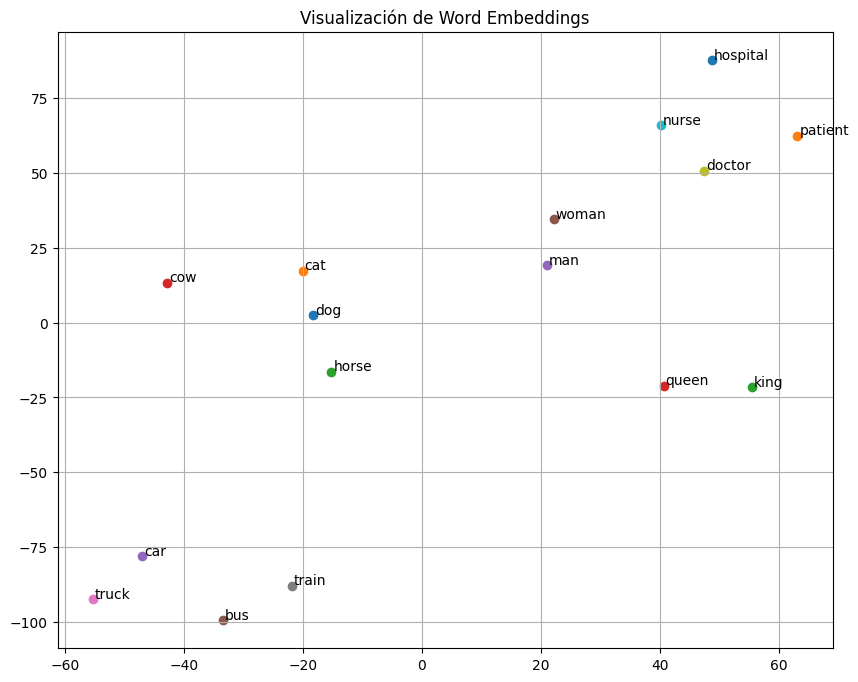

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Palabras que queremos visualizar
words = [
    "dog","cat","horse","cow",
    "car","bus","truck","train",
    "doctor","nurse","hospital","patient",
    "king","queen","man","woman"
]

# Filtrar palabras que existan en el vocabulario
words = [w for w in words if w in model]

# Obtener vectores
vectors = np.array([model[w] for w in words])

# Reducir dimensiones con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(vectors)

# Dibujar gráfico
plt.figure(figsize=(10,8))

for word, (x, y) in zip(words, coords):
    plt.scatter(x, y)
    plt.text(x+0.3, y+0.3, word)

plt.title("Visualización de Word Embeddings")
plt.grid(True)
plt.show()

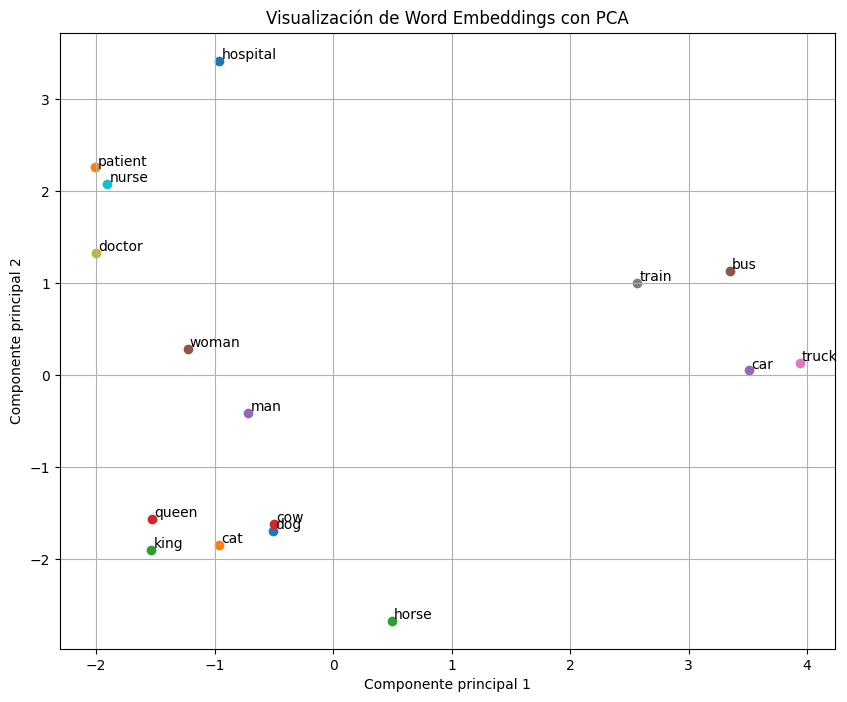

In [ ]:
from sklearn.decomposition import PCA

# Palabras que queremos visualizar
words = [
    "dog","cat","horse","cow",
    "car","bus","truck","train",
    "doctor","nurse","hospital","patient",
    "king","queen","man","woman"
]

# Filtrar palabras que existan en el vocabulario
words = [w for w in words if w in model]

# Obtener los vectores
vectors = np.array([model[w] for w in words])

# Reducir dimensiones con PCA (de 50 → 2)
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Dibujar gráfico
plt.figure(figsize=(10,8))

for word, (x, y) in zip(words, coords):
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word)

plt.title("Visualización de Word Embeddings con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)

plt.show()

## Limitaciones

Explorar casos en los que los embeddings no funcionan correctamente.

Ejemplo:

- "the bank is near the river"

- "I deposited money in the bank"


¿El modelo distingue entre los distintos significados de una palabra?

